In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'

# Create outputs folder
os.makedirs('outputs', exist_ok=True)

print("Libraries imported successfully.")


Libraries imported successfully.


In [7]:
df = pd.read_csv(r"F:\Project Raw Data\IBM Telco\WA_Fn-UseC_-Telco-Customer-Churn.csv")


print(f"Shape : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumns : {list(df.columns)}")


Shape : 7043 rows × 21 columns

Columns : ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [8]:
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
df.dtypes


customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [10]:
# 3.1 Check missing values
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [12]:

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
blank_count = df['TotalCharges'].isnull().sum()
print(f"Blank TotalCharges rows found: {blank_count}")

df['TotalCharges'].fillna(0, inplace=True)
print("Blanks filled with 0 — these are new customers with no charges yet.")


Blank TotalCharges rows found: 0
Blanks filled with 0 — these are new customers with no charges yet.


In [13]:
dupe_count = df.duplicated(subset='customerID').sum()
print(f"Duplicate customerIDs: {dupe_count}")


Duplicate customerIDs: 0


In [14]:
df.rename(columns={
    'customerID'       : 'customer_id',
    'SeniorCitizen'    : 'senior_citizen',
    'Partner'          : 'partner',
    'Dependents'       : 'dependents',
    'tenure'           : 'tenure',
    'PhoneService'     : 'phone_service',
    'MultipleLines'    : 'multiple_lines',
    'InternetService'  : 'internet_service',
    'OnlineSecurity'   : 'online_security',
    'OnlineBackup'     : 'online_backup',
    'DeviceProtection' : 'device_protection',
    'TechSupport'      : 'tech_support',
    'StreamingTV'      : 'streaming_tv',
    'StreamingMovies'  : 'streaming_movies',
    'Contract'         : 'contract',
    'PaperlessBilling' : 'paperless_billing',
    'PaymentMethod'    : 'payment_method',
    'MonthlyCharges'   : 'monthly_charges',
    'TotalCharges'     : 'total_charges',
    'Churn'            : 'churn'
}, inplace=True)

print("Columns renamed to snake_case.")
print(f"Columns now: {list(df.columns)}")


Columns renamed to snake_case.
Columns now: ['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents', 'tenure', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method', 'monthly_charges', 'total_charges', 'churn']


In [16]:
def assign_tenure_group(months):
    if months <= 12:
        return '0–12 Months'
    elif months <= 24:
        return '13–24 Months'
    elif months <= 48:
        return '25–48 Months'
    else:
        return '49–72 Months'

df['tenure_group'] = df['tenure'].apply(assign_tenure_group)

df['senior_label'] = df['senior_citizen'].map({0: 'Non-Senior', 1: 'Senior'})

df['churn_flag'] = df['churn'].map({'Yes': 1, 'No': 0})

print(f"Derived columns added. Final shape: {df.shape}")
print(f"\nChurn distribution:\n{df['churn'].value_counts()}")


Derived columns added. Final shape: (7043, 24)

Churn distribution:
churn
No     5174
Yes    1869
Name: count, dtype: int64


In [19]:
total_customers = len(df)
total_churned = df['churn_flag'].sum()
churn_rate = round(total_churned / total_customers * 100, 2)
total_monthly_rev = round(df['monthly_charges'].sum(), 2)
revenue_at_risk = round(df[df['churn'] == 'Yes']['monthly_charges'].sum(), 2)
avg_monthly_charge = round(df['monthly_charges'].mean(), 2)
avg_tenure_churned = round(df[df['churn'] == 'Yes']['tenure'].mean(), 1)
avg_tenure_active = round(df[df['churn'] == 'No']['tenure'].mean(), 1)

print("-" * 25)
print("KEY BUSINESS KPIs")
print("-" * 25)
print(f"  Total Customers : {total_customers:,}")
print(f"  Churned Customers : {total_churned:,}")
print(f"  Overall Churn Rate : {churn_rate}%")
print(f"  Total Monthly Revenue: ${total_monthly_rev:,.2f}")
print(f"  Monthly Revenue at Risk: ${revenue_at_risk:,.2f}")
print(f"  Avg Monthly Charge : ${avg_monthly_charge}")
print(f"  Avg Tenure (Churned) :{avg_tenure_churned} months")
print(f"  Avg Tenure (Active) :{avg_tenure_active} months")
print("-" * 25)


-------------------------
KEY BUSINESS KPIs
-------------------------
  Total Customers : 7,043
  Churned Customers : 1,869
  Overall Churn Rate : 26.54%
  Total Monthly Revenue: $456,116.60
  Monthly Revenue at Risk: $139,130.85
  Avg Monthly Charge : $64.76
  Avg Tenure (Churned) :18.0 months
  Avg Tenure (Active) :37.6 months
-------------------------


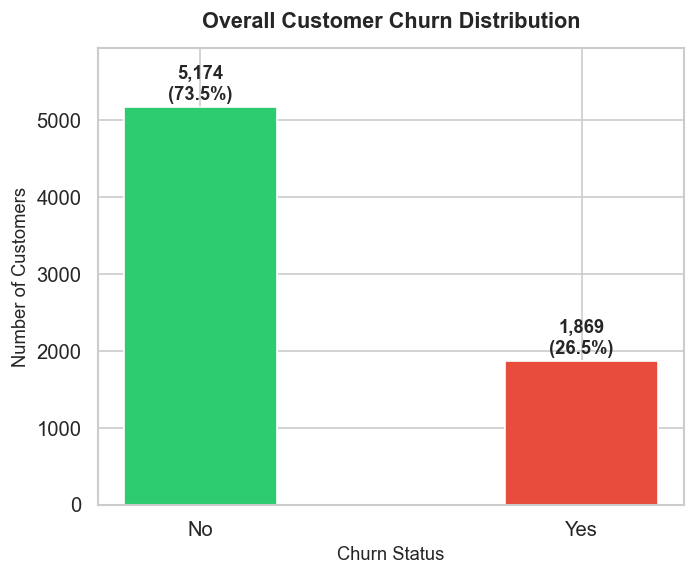

In [20]:
fig, ax = plt.subplots(figsize=(6, 5))
churn_counts = df['churn'].value_counts()
colors = ['#2ecc71', '#e74c3c']

bars = ax.bar(churn_counts.index, churn_counts.values, color=colors, width=0.4, edgecolor='white')

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 50,
        f'{height:,}\n({height/total_customers*100:.1f}%)',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax.set_title('Overall Customer Churn Distribution', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Churn Status', fontsize=11)
ax.set_ylabel('Number of Customers', fontsize=11)
ax.set_ylim(0, churn_counts.max() * 1.15)
plt.tight_layout()
plt.savefig('outputs/01_churn_distribution.png')
plt.show()


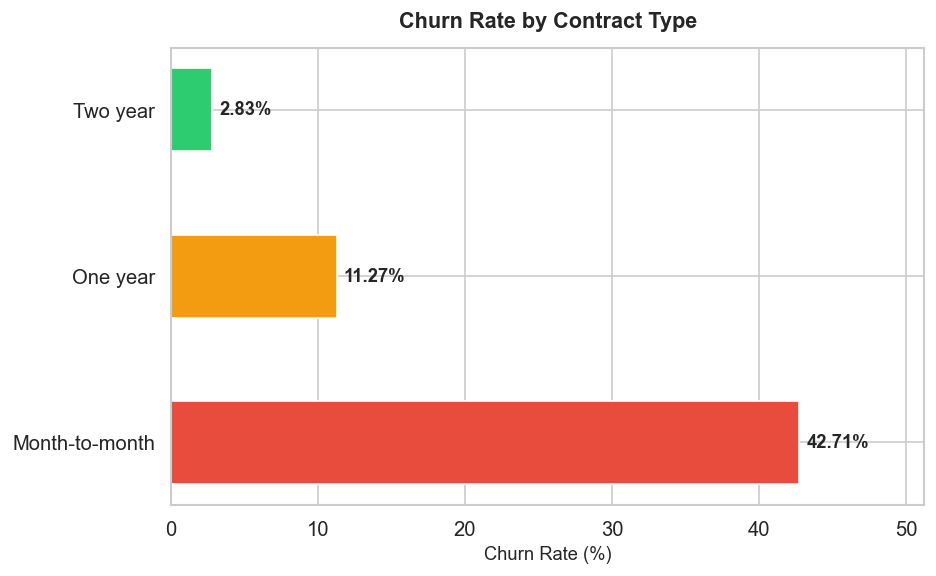

In [21]:
contract_churn = (
    df.groupby('contract')['churn_flag']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'churn_rate', 'count': 'customers'})
)
contract_churn['churn_rate_pct'] = (contract_churn['churn_rate'] * 100).round(2)
contract_churn = contract_churn.sort_values('churn_rate_pct', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bar_colors = ['#e74c3c', '#f39c12', '#2ecc71']
bars = ax.barh(
    contract_churn['contract'],
    contract_churn['churn_rate_pct'],
    color=bar_colors, edgecolor='white', height=0.5
)

for bar, val in zip(bars, contract_churn['churn_rate_pct']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val}%', va='center', fontsize=11, fontweight='bold')

ax.set_title('Churn Rate by Contract Type', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Churn Rate (%)', fontsize=11)
ax.set_xlim(0, contract_churn['churn_rate_pct'].max() * 1.2)
plt.tight_layout()
plt.savefig('outputs/02_churn_by_contract.png')
plt.show()


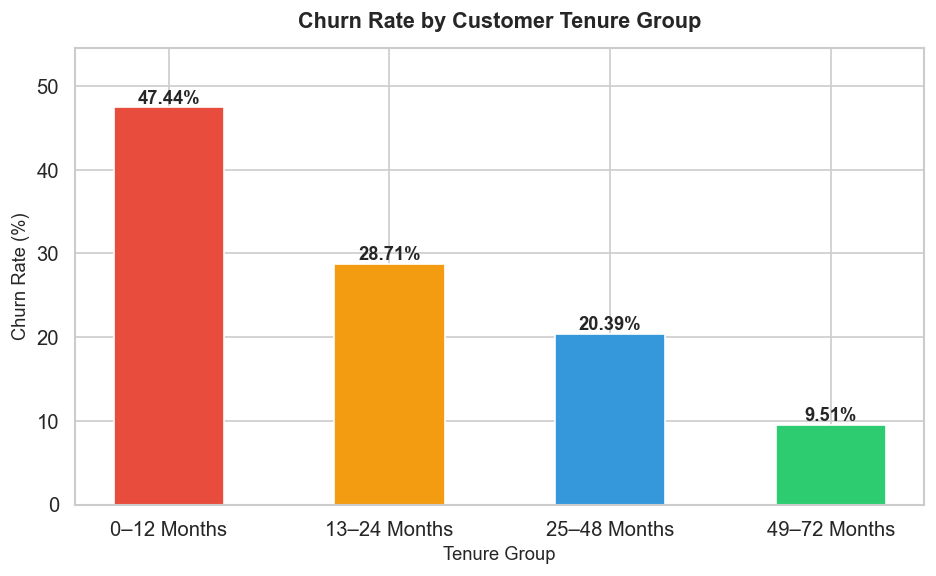

In [22]:
tenure_order = ['0–12 Months', '13–24 Months', '25–48 Months', '49–72 Months']

tenure_churn = (
    df.groupby('tenure_group')['churn_flag']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'churn_rate', 'count': 'customers'})
)
tenure_churn['churn_rate_pct'] = (tenure_churn['churn_rate'] * 100).round(2)
tenure_churn['tenure_group'] = pd.Categorical(tenure_churn['tenure_group'], categories=tenure_order, ordered=True)
tenure_churn = tenure_churn.sort_values('tenure_group')

fig, ax = plt.subplots(figsize=(8, 5))
palette = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']
bars = ax.bar(
    tenure_churn['tenure_group'],
    tenure_churn['churn_rate_pct'],
    color=palette, edgecolor='white', width=0.5
)

for bar, val in zip(bars, tenure_churn['churn_rate_pct']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{val}%', ha='center', fontsize=11, fontweight='bold')

ax.set_title('Churn Rate by Customer Tenure Group', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Tenure Group', fontsize=11)
ax.set_ylabel('Churn Rate (%)', fontsize=11)
ax.set_ylim(0, tenure_churn['churn_rate_pct'].max() * 1.15)
plt.tight_layout()
plt.savefig('outputs/03_churn_by_tenure_group.png')
plt.show()


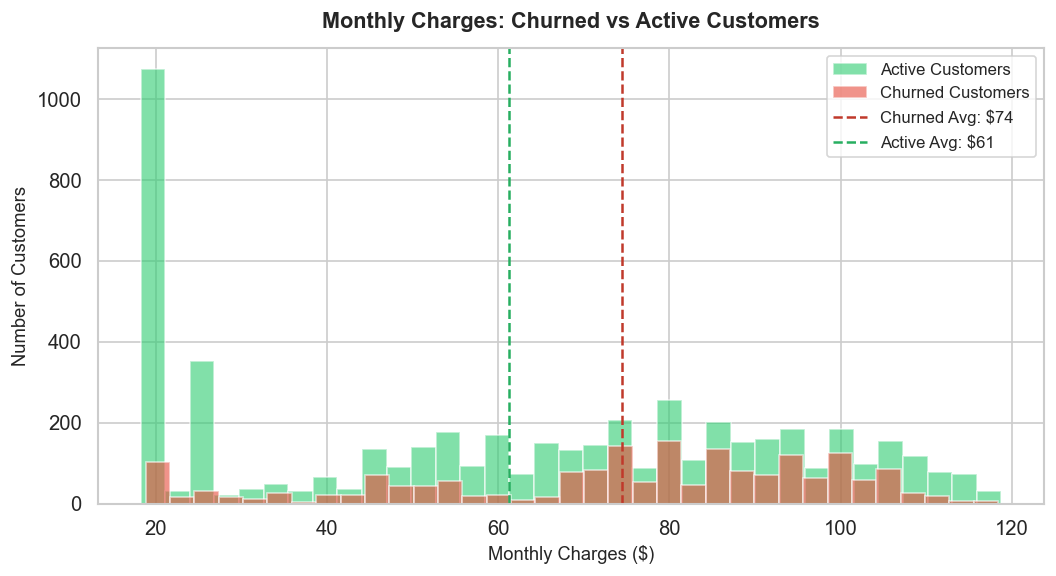

In [23]:
fig, ax = plt.subplots(figsize=(9, 5))

for churn_val, color, label in zip(
    ['No', 'Yes'],
    ['#2ecc71', '#e74c3c'],
    ['Active Customers', 'Churned Customers']
):
    subset = df[df['churn'] == churn_val]['monthly_charges']
    ax.hist(subset, bins=35, alpha=0.6, color=color, label=label, edgecolor='white')

ax.axvline(
    df[df['churn'] == 'Yes']['monthly_charges'].mean(),
    color='#c0392b', linestyle='--', linewidth=1.5,
    label=f"Churned Avg: ${df[df['churn']=='Yes']['monthly_charges'].mean():.0f}"
)
ax.axvline(
    df[df['churn'] == 'No']['monthly_charges'].mean(),
    color='#27ae60', linestyle='--', linewidth=1.5,
    label=f"Active Avg: ${df[df['churn']=='No']['monthly_charges'].mean():.0f}"
)

ax.set_title('Monthly Charges: Churned vs Active Customers', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Monthly Charges ($)', fontsize=11)
ax.set_ylabel('Number of Customers', fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('outputs/04_monthly_charges_distribution.png')
plt.show()


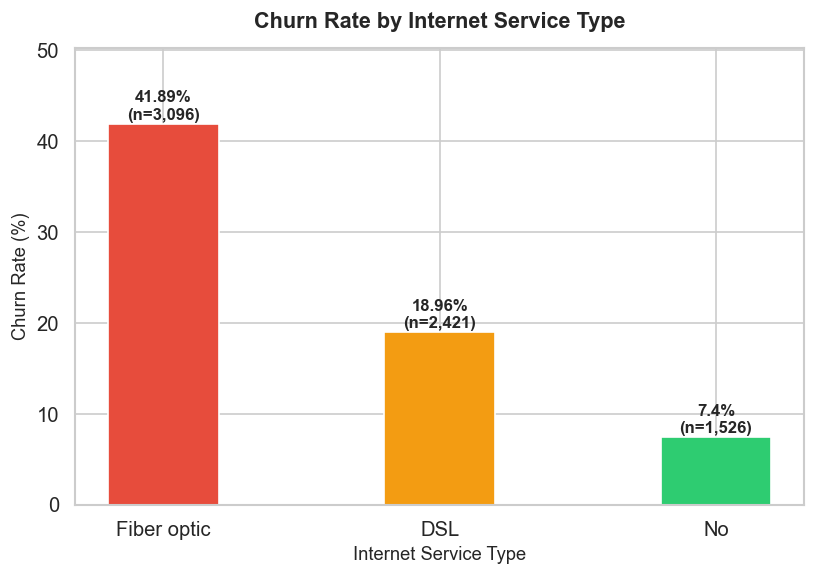

In [24]:
internet_churn = (
    df.groupby('internet_service')['churn_flag']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'churn_rate', 'count': 'customers'})
)
internet_churn['churn_rate_pct'] = (internet_churn['churn_rate'] * 100).round(2)
internet_churn = internet_churn.sort_values('churn_rate_pct', ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
colors = ['#e74c3c', '#f39c12', '#2ecc71']
bars = ax.bar(
    internet_churn['internet_service'],
    internet_churn['churn_rate_pct'],
    color=colors, edgecolor='white', width=0.4
)

for bar, val, count in zip(bars, internet_churn['churn_rate_pct'], internet_churn['customers']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{val}%\n(n={count:,})',
        ha='center', fontsize=10, fontweight='bold'
    )

ax.set_title('Churn Rate by Internet Service Type', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Internet Service Type', fontsize=11)
ax.set_ylabel('Churn Rate (%)', fontsize=11)
ax.set_ylim(0, internet_churn['churn_rate_pct'].max() * 1.2)
plt.tight_layout()
plt.savefig('outputs/05_churn_by_internet_service.png')
plt.show()


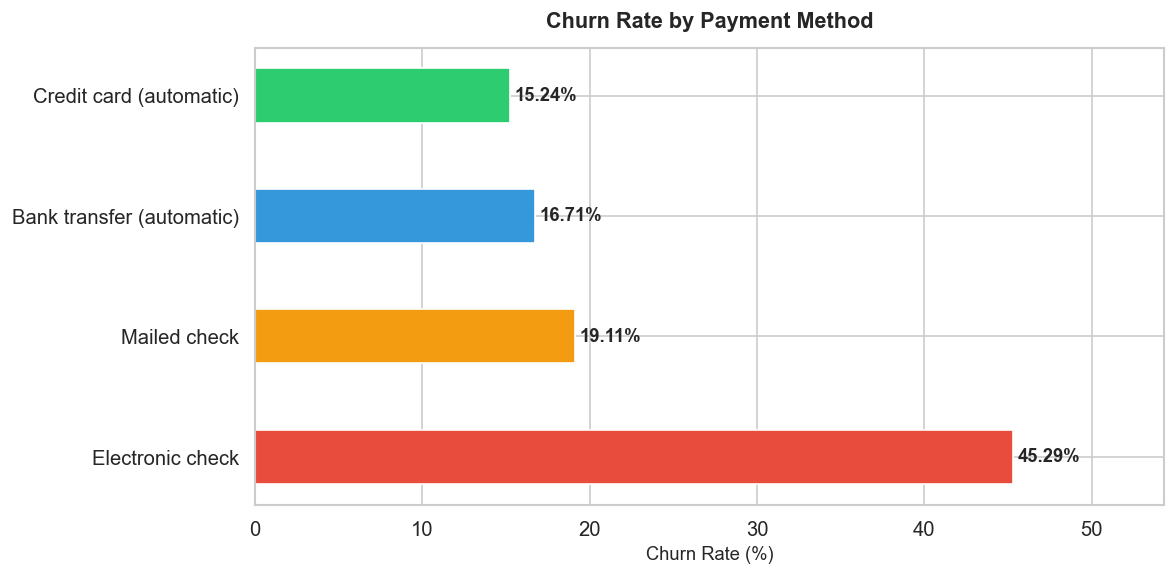

In [25]:
payment_churn = (
    df.groupby('payment_method')['churn_flag']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'churn_rate', 'count': 'customers'})
)
payment_churn['churn_rate_pct'] = (payment_churn['churn_rate'] * 100).round(2)
payment_churn = payment_churn.sort_values('churn_rate_pct', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']
bars = ax.barh(
    payment_churn['payment_method'],
    payment_churn['churn_rate_pct'],
    color=colors, edgecolor='white', height=0.45
)

for bar, val in zip(bars, payment_churn['churn_rate_pct']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val}%', va='center', fontsize=11, fontweight='bold')

ax.set_title('Churn Rate by Payment Method', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Churn Rate (%)', fontsize=11)
ax.set_xlim(0, payment_churn['churn_rate_pct'].max() * 1.2)
plt.tight_layout()
plt.savefig('outputs/06_churn_by_payment_method.png')
plt.show()


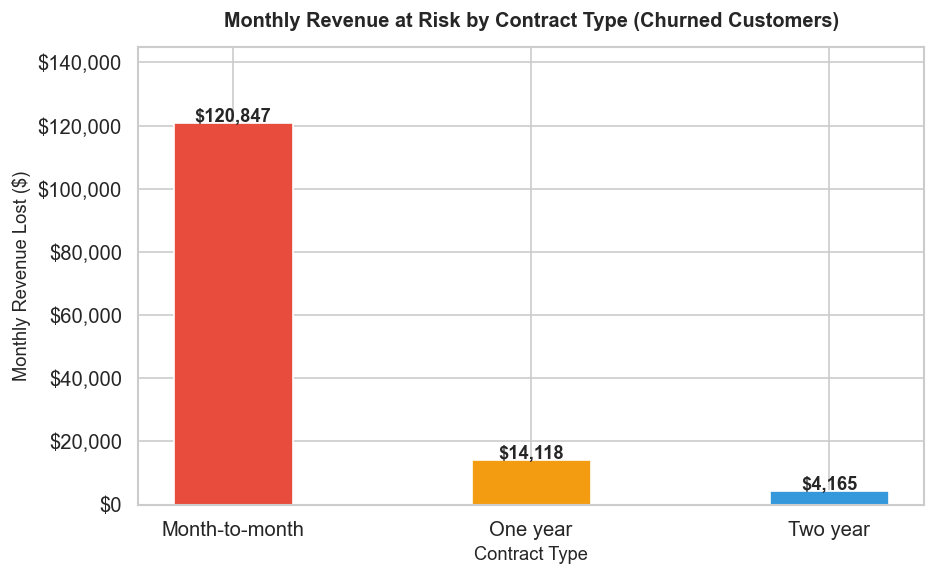

In [26]:
rev_by_contract = (
    df[df['churn'] == 'Yes']
    .groupby('contract')['monthly_charges']
    .sum()
    .reset_index()
    .rename(columns={'monthly_charges': 'revenue_at_risk'})
    .sort_values('revenue_at_risk', ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    rev_by_contract['contract'],
    rev_by_contract['revenue_at_risk'],
    color=['#e74c3c', '#f39c12', '#3498db'],
    edgecolor='white', width=0.4
)

for bar, val in zip(bars, rev_by_contract['revenue_at_risk']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 500,
        f'${val:,.0f}',
        ha='center', fontsize=11, fontweight='bold'
    )

ax.set_title('Monthly Revenue at Risk by Contract Type (Churned Customers)',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Contract Type', fontsize=11)
ax.set_ylabel('Monthly Revenue Lost ($)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_ylim(0, rev_by_contract['revenue_at_risk'].max() * 1.2)
plt.tight_layout()
plt.savefig('outputs/07_revenue_at_risk_by_contract.png')
plt.show()


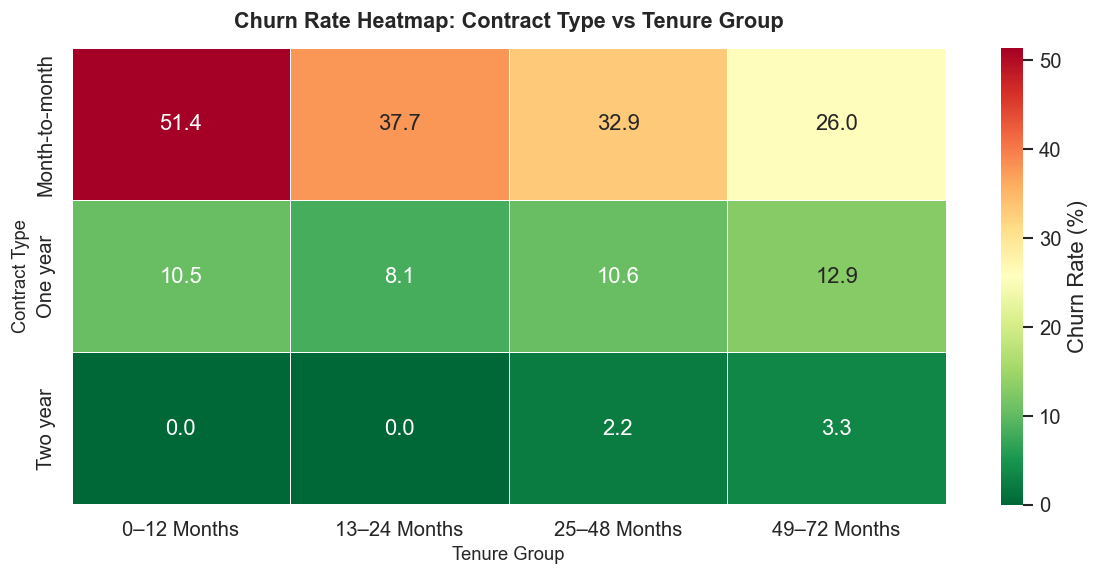

In [27]:
tenure_order = ['0–12 Months', '13–24 Months', '25–48 Months', '49–72 Months']

pivot_data = df.groupby(['contract', 'tenure_group'])['churn_flag'].mean().unstack()
pivot_data = pivot_data[tenure_order]  # enforce column order

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    pivot_data * 100,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn_r',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Churn Rate (%)'},
    ax=ax
)
ax.set_title('Churn Rate Heatmap: Contract Type vs Tenure Group',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Tenure Group', fontsize=11)
ax.set_ylabel('Contract Type', fontsize=11)
plt.tight_layout()
plt.savefig('outputs/08_churn_heatmap_contract_tenure.png')
plt.show()


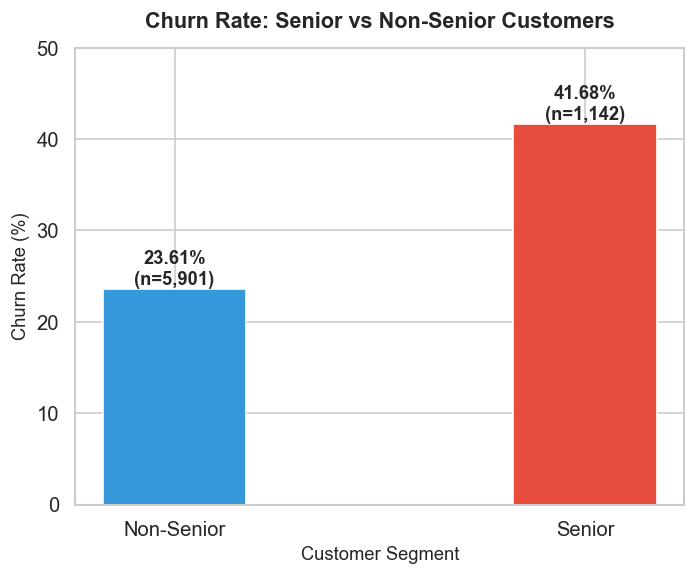

In [28]:
senior_churn = (
    df.groupby('senior_label')['churn_flag']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'churn_rate', 'count': 'customers'})
)
senior_churn['churn_rate_pct'] = (senior_churn['churn_rate'] * 100).round(2)

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(
    senior_churn['senior_label'],
    senior_churn['churn_rate_pct'],
    color=['#3498db', '#e74c3c'],
    edgecolor='white', width=0.35
)

for bar, val, count in zip(bars, senior_churn['churn_rate_pct'], senior_churn['customers']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{val}%\n(n={count:,})',
        ha='center', fontsize=11, fontweight='bold'
    )

ax.set_title('Churn Rate: Senior vs Non-Senior Customers', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Customer Segment', fontsize=11)
ax.set_ylabel('Churn Rate (%)', fontsize=11)
ax.set_ylim(0, senior_churn['churn_rate_pct'].max() * 1.2)
plt.tight_layout()
plt.savefig('outputs/09_churn_senior_vs_non_senior.png')
plt.show()


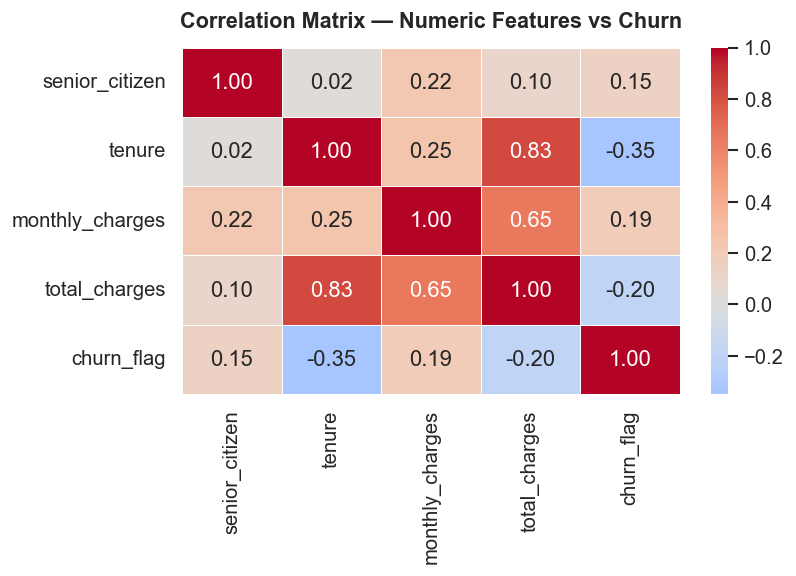

In [29]:
numeric_cols = ['senior_citizen', 'tenure', 'monthly_charges', 'total_charges', 'churn_flag']
corr_matrix = df[numeric_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    linecolor='white',
    ax=ax
)
ax.set_title('Correlation Matrix — Numeric Features vs Churn', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('outputs/10_correlation_heatmap.png')
plt.show()


In [31]:
high_risk = df[
    (df['contract'] == 'Month-to-month') &
    (df['tenure']  <= 12) &
    (df['payment_method'] == 'Electronic check') &
    (df['internet_service'] == 'Fiber optic') &
    (df['churn']  == 'No')   
]

print("-" * 30)
print("HIGH-RISK CUSTOMER SEGMENT")
print("-" * 30)
print(f"  Customers Identified    : {len(high_risk)}")
print(f"  Monthly Revenue at Stake: ${high_risk['monthly_charges'].sum():,.2f}")
print(f"  Avg Monthly Charge      : ${high_risk['monthly_charges'].mean():.2f}")
print("-" * 30)


------------------------------
HIGH-RISK CUSTOMER SEGMENT
------------------------------
  Customers Identified    : 182
  Monthly Revenue at Stake: $14,768.95
  Avg Monthly Charge      : $81.15
------------------------------


In [32]:
print("Sample of high-risk active customers (first 10):")
high_risk[['customer_id', 'contract', 'tenure', 'payment_method',
           'monthly_charges', 'total_charges']].head(10)


Sample of high-risk active customers (first 10):


,customer_id,contract,tenure,payment_method,monthly_charges,total_charges
91,2424-WVHPL,Month-to-month,1,Electronic check,74.70,74.70
115,3071-VBYPO,Month-to-month,3,Electronic check,89.85,248.40
162,4482-EWFMI,Month-to-month,2,Electronic check,69.70,135.20
245,0221-WMXNQ,Month-to-month,4,Electronic check,75.35,273.40
293,4847-TAJYI,Month-to-month,6,Electronic check,89.35,567.80
302,8266-VBFQL,Month-to-month,4,Electronic check,90.40,356.65
313,2799-ARNLO,Month-to-month,5,Electronic check,69.35,341.60
326,5701-YVSVF,Month-to-month,11,Electronic check,82.90,880.05
345,0021-IKXGC,Month-to-month,1,Electronic check,72.10,72.10
352,4115-NZRKS,Month-to-month,7,Electronic check,89.15,574.35


In [33]:
print("-" * 55)
print("ANALYSIS COMPLETE - SUMMARY")
print("-" * 55)
print(f"Total Customers Analyzed : {total_customers:,}")
print(f"Overall Churn Rate  : {churn_rate}%")
print(f"Monthly Revenue at Risk : ${revenue_at_risk:,.2f}")
print(f"High-Risk Active Customers : {len(high_risk)}")
print("\n  All 10 charts saved to /outputs/")
print("-" * 55)


-------------------------------------------------------
ANALYSIS COMPLETE - SUMMARY
-------------------------------------------------------
Total Customers Analyzed : 7,043
Overall Churn Rate  : 26.54%
Monthly Revenue at Risk : $139,130.85
High-Risk Active Customers : 182

  All 10 charts saved to /outputs/
-------------------------------------------------------
